<a href="https://colab.research.google.com/github/puccash/Data_Test/blob/Data-Test/Master_251017_ipynb_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1-1. 구글 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# # 한글 깨짐 방지
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [3]:
# 1-2. 라이브러리 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium # 지도 시각화를 위한 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
## data = pd.read_csv('/content/drive/MyDrive/01. 공모전/03. 빅콘테스트/data/master_data.csv', encoding='cp949')
data = pd.read_csv('/content/drive/MyDrive/master_data.csv', encoding='cp949')

In [5]:
for col in data.select_dtypes(include=['float']).columns:
    data[col] = data[col].fillna(0).astype(int)
data.head()

,가맹점ID,기준년월,운영개월수구간,매출금액구간,매출건수구간,고객수구간,객단가구간,취소율구간,배달매출비율,업종내매출순위비율,상권내매출순위비율,업종내폐업비율,상권내폐업비율,남성20대이하비율,남성30대비율,남성40대비율,남성50대비율,남성60대이상비율,여성20대이하비율,여성30대비율,여성40대비율,여성50대비율,여성60대이상비율,재방문율,신규고객비율,거주고객비율,직장고객비율,유동고객비율,MCT_BSE_AR,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,폐업여부,프랜차이즈여부,업종_대분류,상권_여부
0,000F03E44A,2024-04-01,4,5,5,5,5,1,1,4,4,2,2,4,2,2,4,4,2,1,1,1,3,1,4,1,3,4,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
1,000F03E44A,2023-12-01,4,6,6,6,6,1,1,4,4,2,2,3,4,1,4,1,2,3,1,3,1,1,1,1,3,5,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
2,002816BA73,2024-04-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,2,2,4,3,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
3,002816BA73,2024-11-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,4,1,1,2,2,2,1,2,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
4,002816BA73,2024-06-01,2,4,4,4,2,1,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,1,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1


In [6]:
# 상권 위험도 분석
# 상권별 평균적인 특성을 보기 위해 그룹화 및 집계
district_df = data.groupby('상권').agg(
    store_count=('가맹점ID', 'nunique'), # 상권 내 가맹점 수
    avg_closure_rate=('상권내폐업비율', 'mean'), # 상권 내 평균 폐업률 (높을수록 위험)
    avg_sales_rank=('상권내매출순위비율', 'mean'), # 상권 내 평균 매출 순위 비율 (낮을수록 상위권)
    avg_industry_closure_rate=('업종내폐업비율', 'mean') # 상권 내 업종 평균 폐업률 (높을수록 위험)
).reset_index()

print("\n--- 상권별 집계 데이터프레임 (district_df) ---")
display(district_df)


--- 상권별 집계 데이터프레임 (district_df) ---


,상권,store_count,avg_closure_rate,avg_sales_rank,avg_industry_closure_rate
0,건대입구,1,4.000000,2.916667,2.000000
1,금남시장,249,2.913404,2.720068,1.737575
2,답십리,179,2.608671,2.488327,1.707893
3,동대문역사문화공원역,1,2.333333,4.000000,1.083333
4,뚝섬,468,2.641714,2.311013,1.796084
5,마장동,257,1.917837,2.732971,1.272472
6,미아사거리,1,4.000000,4.000000,2.000000
7,방배역,1,3.625000,4.000000,1.041667
8,상권없음,1047,1.000000,0.000000,1.691816
9,서면역,1,4.000000,1.000000,0.958333


In [7]:
# 1-1. 상권내 폐업비율 구간별로 상권 분류 (안정 vs 위험)
# 사분위수를 기준으로 '안정', '주의', '위험', '고위험' 4등급으로 분류
# 폐업률은 높을수록 위험도가 높습니다.
district_df['위험도등급'] = pd.qcut(
    district_df['avg_closure_rate'],
    q=4,
    labels=['안정', '주의', '위험', '고위험']
)

print("--- 폐업률 기반 상권 위험도 분류 결과 (위험도 높은 순) ---")
display(district_df[['상권', 'avg_closure_rate', '위험도등급']].sort_values('avg_closure_rate', ascending=False))

--- 폐업률 기반 상권 위험도 분류 결과 (위험도 높은 순) ---


,상권,avg_closure_rate,위험도등급
0,건대입구,4.000000,고위험
18,풍산지구,4.000000,고위험
21,화양시장,4.000000,고위험
13,오남,4.000000,고위험
9,서면역,4.000000,고위험
6,미아사거리,4.000000,고위험
15,왕십리,3.871218,위험
20,행당,3.737357,위험
19,한양대,3.645500,위험
7,방배역,3.625000,위험


/tmp/ipython-input-1511086801.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_analysis = df_with_risk.groupby('위험도등급')['업종내폐업비율'].mean()
/tmp/ipython-input-1511086801.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_analysis.index, y=correlation_analysis.values, palette='viridis', order=['안정', '주의', '위험', '고위험'])



--- 상권 위험도별 평균 업종 폐업률 ---
위험도등급
안정     1.659042
주의     1.818721
위험     1.758408
고위험    1.869919
Name: 업종내폐업비율, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


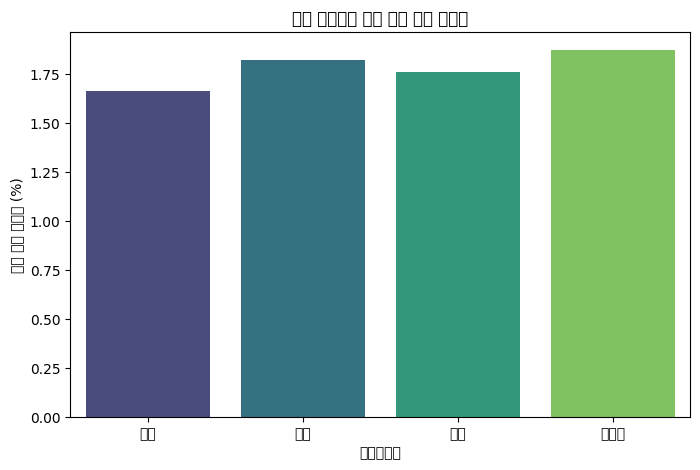

In [8]:
# 1-2. 업종별 폐업률과 상권 폐업률의 상관관계 분석
# 각 상권의 위험도 등급을 원본 데이터프레임에 병합
df_with_risk = pd.merge(data, district_df[['상권', '위험도등급']], on='상권', how='left')

# 상권 위험도 등급별로 업종 폐업률의 평균을 계산
correlation_analysis = df_with_risk.groupby('위험도등급')['업종내폐업비율'].mean()

print("\n--- 상권 위험도별 평균 업종 폐업률 ---")
print(correlation_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(x=correlation_analysis.index, y=correlation_analysis.values, palette='viridis', order=['안정', '주의', '위험', '고위험'])
plt.title('상권 위험도에 따른 평균 업종 폐업률')
plt.ylabel('평균 업종 폐업률 (%)')
plt.show()

--- 매출 순위 비율 vs 폐업률 상관계수 ---
avg_sales_rank는 1에 가까울수록 상위권(좋음)을 의미합니다.
따라서 폐업률(avg_closure_rate)과 양의 상관관계가 나타나면, '순위가 낮아질수록(숫자가 커질수록) 폐업률이 높아진다'는 의미입니다.


,avg_sales_rank,avg_closure_rate
avg_sales_rank,1.000000,0.075529
avg_closure_rate,0.075529,1.000000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

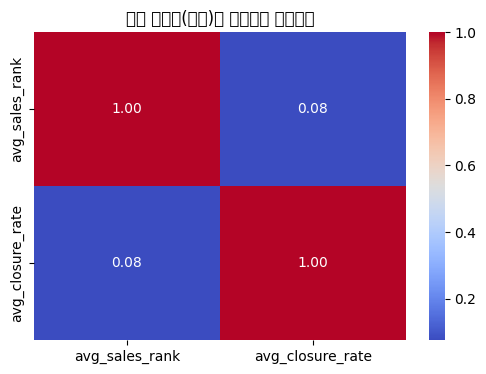


--- 매출 상위 Top 10 상권의 안정성(위험도) ---


,상권,avg_sales_rank,avg_closure_rate,위험도등급
9,서면역,1.000000,4.000000,고위험
10,성수,2.223404,2.660456,주의
4,뚝섬,2.311013,2.641714,안정
14,옥수,2.412432,2.688038,주의
2,답십리,2.488327,2.608671,안정
17,장한평자동차,2.490123,2.000000,안정
20,행당,2.591626,3.737357,위험
15,왕십리,2.658268,3.871218,위험
11,신금호,2.679635,3.547550,위험
19,한양대,2.690795,3.645500,위험



--- 업종별 평균 매출 집중도와 폐업률 ---


,avg_sales_rank,avg_closure_rate
업종_대분류,,
중식,1.947115,2.983774
한식-육류/고기,1.970544,3.049459
일식,2.095649,3.037108
한식-해물/생선,2.129612,3.038316
세계요리,2.155887,3.049751


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

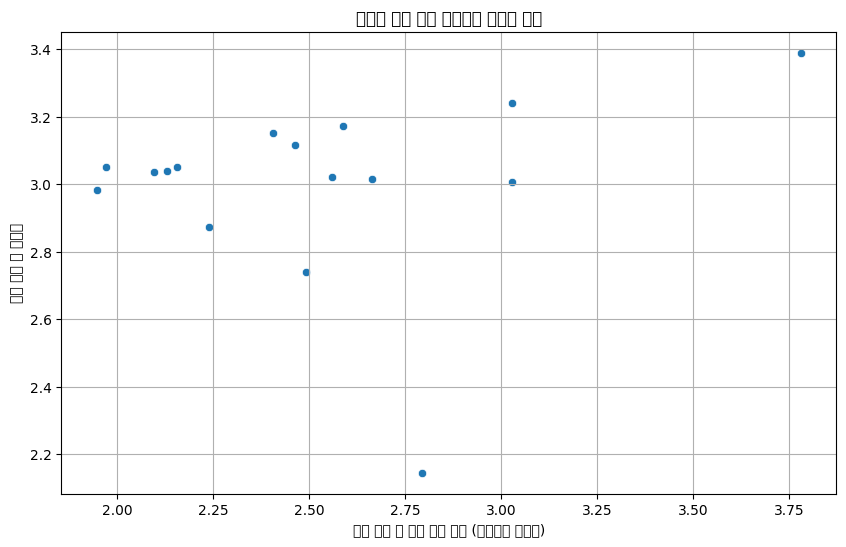

In [9]:
# 2-1. 상권내매출순위비율 vs 상권내폐업비율 간 상관계수
# '상권없음' 데이터는 순위가 0으로 왜곡되어 있으므로 제외하고 분석
corr_df = district_df[district_df['상권']!= '상권없음']
correlation = corr_df[['avg_sales_rank', 'avg_closure_rate']].corr()

print("--- 매출 순위 비율 vs 폐업률 상관계수 ---")
print("avg_sales_rank는 1에 가까울수록 상위권(좋음)을 의미합니다.")
print("따라서 폐업률(avg_closure_rate)과 양의 상관관계가 나타나면, '순위가 낮아질수록(숫자가 커질수록) 폐업률이 높아진다'는 의미입니다.")
display(correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('매출 집중도(순위)와 폐업률의 상관관계')
plt.show()

# 2-2. 매출 상위 상권이 실제로 안정적인지 검증
# 매출 순위 비율이 낮은(상위권) 상권 Top 10 추출
top_sales_districts = corr_df.sort_values('avg_sales_rank').head(10)

print("\n--- 매출 상위 Top 10 상권의 안정성(위험도) ---")
display(top_sales_districts[['상권', 'avg_sales_rank', 'avg_closure_rate', '위험도등급']])

# 2-3. 업종별로 매출 집중도와 폐업률 비교
# 업종별로 상권 내 평균 매출 순위와 폐업률 계산
industry_vs_sales_closure = data[data['상권']!= '상권없음'].groupby('업종_대분류').agg(
    avg_sales_rank=('상권내매출순위비율', 'mean'),
    avg_closure_rate=('상권내폐업비율', 'mean')
).dropna()

print("\n--- 업종별 평균 매출 집중도와 폐업률 ---")
display(industry_vs_sales_closure.sort_values('avg_sales_rank').head())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=industry_vs_sales_closure, x='avg_sales_rank', y='avg_closure_rate')
plt.title('업종별 평균 매출 집중도와 폐업률 관계')
plt.xlabel('평균 상권 내 매출 순위 비율 (낮을수록 상위권)')
plt.ylabel('평균 상권 내 폐업률')
plt.grid(True)
plt.show()

/tmp/ipython-input-226205524.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  suitability_pivot = df_with_risk.pivot_table(


--- 업종별 상권 위험도 분포 (비율 %) ---
예: '한식' 업종의 가맹점 중 몇 %가 '안정' 등급의 상권에 위치하는지를 보여줍니다.


위험도등급,안정,주의,위험,고위험
업종_대분류,,,,
건강식품/건강원,21.212121,27.272727,51.515152,0.000000
기타,31.914894,26.595745,41.489362,0.000000
분식/패스트푸드,45.495495,24.774775,29.729730,0.000000
세계요리,52.272727,27.272727,18.181818,2.272727
식료품/식자재,54.736842,24.210526,20.701754,0.350877
양식,50.847458,35.593220,12.429379,1.129944
일식,39.800995,34.328358,25.870647,0.000000
주점,32.432432,30.501931,37.065637,0.000000
중식,44.339623,31.132075,24.528302,0.000000


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/

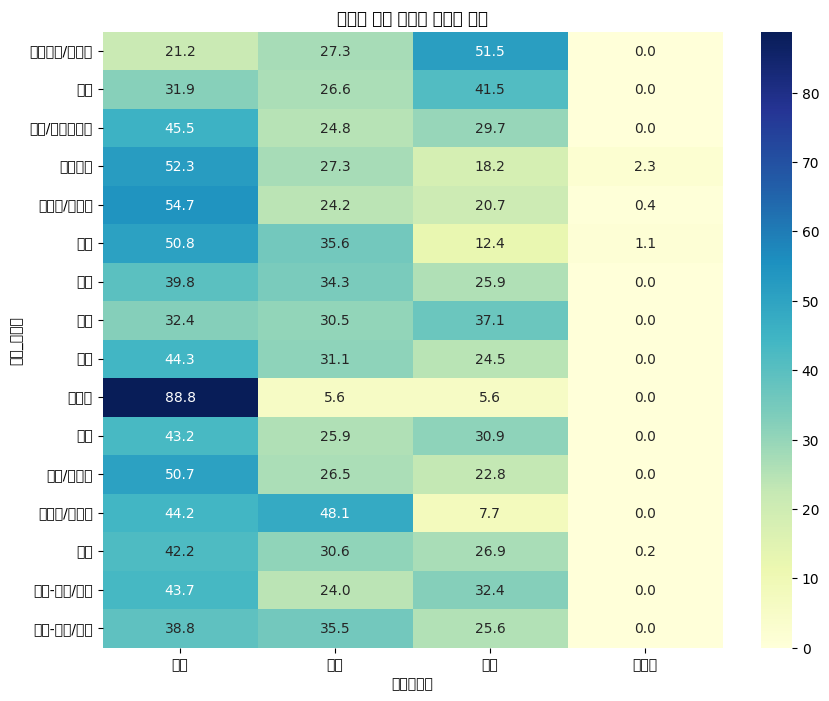


--- 업종별 (매출 비율 vs 폐업률) 상관계수 ---
상관계수가 음수(-)이면 '매출 비율이 높을수록 폐업률이 낮아진다'는 긍정적인 관계를 의미합니다.
업종_대분류
한식-육류/고기   -0.459684
식료품/식자재    -0.412990
치킨         -0.402335
주점         -0.381056
축산물        -0.357863
카페/디저트     -0.126710
분식/패스트푸드   -0.115565
중식         -0.115115
칵테일/와인바    -0.105367
일식          0.014181
한식-해물/생선    0.031964
기타          0.045563
한식          0.093708
세계요리        0.245253
건강식품/건강원    0.297222
양식          0.392684
Name: (avg_sales_ratio, avg_closure_rate), dtype: float64


In [10]:
# 3-1 & 3-2. 업종별로 "안정 상권"과 "위험 상권" 매핑
# df_with_risk는 1-3 단계에서 이미 생성됨

# 업종별로 각 위험도 등급의 상권에 몇 개의 가맹점이 있는지 카운트
suitability_pivot = df_with_risk.pivot_table(
    index='업종_대분류',
    columns='위험도등급',
    values='가맹점ID',
    aggfunc='nunique',
    fill_value=0
)

# 각 업종별 총 가맹점 수로 나누어 비율로 변환
suitability_pivot_ratio = suitability_pivot.div(suitability_pivot.sum(axis=1), axis=0) * 100

print("--- 업종별 상권 위험도 분포 (비율 %) ---")
print("예: '한식' 업종의 가맹점 중 몇 %가 '안정' 등급의 상권에 위치하는지를 보여줍니다.")
display(suitability_pivot_ratio)

plt.figure(figsize=(10, 8))
sns.heatmap(suitability_pivot_ratio, annot=True, cmap="YlGnBu", fmt='.1f')
plt.title('업종별 상권 위험도 적합도 분석')
plt.show()

# 3-3. 업종별 매출 비율이 높은 상권에서 폐업률이 낮은지 확인
# '매입율'은 '업종내매출비율'로 대체하여 분석
# '업종내매출비율'은 100%가 평균이므로 높을수록 좋은 지표입니다.
industry_performance_df = data.groupby(['상권', '업종_대분류']).agg(
    avg_sales_ratio=('업종내매출순위비율', 'mean'), # 업종 평균 대비 매출 비율 (높을수록 좋음)
    avg_closure_rate=('상권내폐업비율', 'mean') # 상권 내 폐업률 (높을수록 나쁨)
).reset_index().dropna()

# 업종별로 매출 비율과 폐업률의 상관관계 계산
correlation_by_industry = industry_performance_df.groupby('업종_대분류')[['avg_sales_ratio', 'avg_closure_rate']].corr().unstack().iloc[:, 1]

print("\n--- 업종별 (매출 비율 vs 폐업률) 상관계수 ---")
print("상관계수가 음수(-)이면 '매출 비율이 높을수록 폐업률이 낮아진다'는 긍정적인 관계를 의미합니다.")
print(correlation_by_industry.sort_values())

In [11]:
from sklearn.tree import DecisionTreeClassifier # 의사결정나무 모델
# 4-1. 모델링을 위한 데이터 준비
# '상권없음' 데이터는 제외
model_df = district_df[district_df['상권']!= '상권없음'].copy()

# 업종 구성 변수 추가 (각 상권의 업종 다양성)
industry_diversity = data.groupby('상권')['업종_대분류'].nunique().reset_index()
industry_diversity.rename(columns={'업종_대분류': '업종다양성'}, inplace=True)
model_df = pd.merge(model_df, industry_diversity, on='상권')

# 4-2. 타겟 변수 생성: 폐업률이 하위 50% (중앙값) 미만이면 '안정'(1), 이상이면 '위험'(0)
median_closure_rate = model_df['avg_closure_rate'].median()
model_df['is_stable'] = (model_df['avg_closure_rate'] < median_closure_rate).astype(int)

print("--- 모델링 데이터셋 및 타겟 변수 생성 결과 ---")
display(model_df.head())
print("\n안정(1)/위험(0) 그룹 분포:\n", model_df['is_stable'].value_counts())

# 4-3. 입력 변수(X)와 타겟 변수(y) 설정
# avg_sales_rank는 낮을수록 좋은 지표. 모델이 이 관계를 학습할 것입니다.
features = ['store_count', 'avg_sales_rank', 'avg_industry_closure_rate', '업종다양성']
X = model_df[features]
y = model_df['is_stable']

# 4-4. 데이터 분할 및 모델 학습/평가
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 로지스틱 회귀 모델
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("\n--- 상권 안정성 예측 모델 평가 결과 (로지스틱 회귀) ---")
print(classification_report(y_test, y_pred_lr, target_names=['위험(0)', '안정(1)']))

# 의사결정나무 모델
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n--- 상권 안정성 예측 모델 평가 결과 (의사결정나무) ---")
print(classification_report(y_test, y_pred_dt, target_names=['위험(0)', '안정(1)']))

--- 모델링 데이터셋 및 타겟 변수 생성 결과 ---


,상권,store_count,avg_closure_rate,avg_sales_rank,avg_industry_closure_rate,위험도등급,업종다양성,is_stable
0,건대입구,1,4.000000,2.916667,2.000000,고위험,1,0
1,금남시장,249,2.913404,2.720068,1.737575,주의,16,1
2,답십리,179,2.608671,2.488327,1.707893,안정,15,1
3,동대문역사문화공원역,1,2.333333,4.000000,1.083333,안정,1,1
4,뚝섬,468,2.641714,2.311013,1.796084,안정,16,1



안정(1)/위험(0) 그룹 분포:
 is_stable
0    11
1    10
Name: count, dtype: int64

--- 상권 안정성 예측 모델 평가 결과 (로지스틱 회귀) ---
              precision    recall  f1-score   support

       위험(0)       1.00      0.50      0.67         4
       안정(1)       0.60      1.00      0.75         3

    accuracy                           0.71         7
   macro avg       0.80      0.75      0.71         7
weighted avg       0.83      0.71      0.70         7


--- 상권 안정성 예측 모델 평가 결과 (의사결정나무) ---
              precision    recall  f1-score   support

       위험(0)       1.00      0.50      0.67         4
       안정(1)       0.60      1.00      0.75         3

    accuracy                           0.71         7
   macro avg       0.80      0.75      0.71         7
weighted avg       0.83      0.71      0.70         7



In [12]:
def generate_district_report(district_name, report_df, full_df):
    """
    특정 상권에 대한 요약 리포트를 생성하는 함수
    """
    try:
        # ✅ 상권 정보 추출 (iloc[0]로 수정)
        district_info = report_df[report_df['상권'] == district_name].iloc[0]

        # 주요 업종 Top3
        top_industries = (
            full_df[full_df['상권'] == district_name]['업종_대분류']
            .value_counts()
            .head(3)
            .index
            .tolist()
        )

        # 리포트 출력
        report = f"""
        ========================================
        상권 [{district_name}] 요약 리포트
        ========================================
        - 상권 위험도: {district_info['위험도등급']}
        - 평균 폐업률: {district_info['avg_closure_rate']:.2f}%
        - 평균 매출 순위 비율: {district_info['avg_sales_rank']:.2f} (1에 가까울수록 상위권)
        - 가맹점 수: {int(district_info['store_count'])}개
        - 주요 업종: {', '.join(top_industries)}

        [종합 의견]
        '{district_name}' 상권은 폐업률 기준 '{district_info['위험도등급']}' 등급으로 평가됩니다.
        주요 업종은 '{', '.join(top_industries)}'이며, 이 업종들의 성과가 상권 전체의 안정성에 큰 영향을 미칩니다.
        상권 내 평균 매출 순위는 {district_info['avg_sales_rank']:.2f} 수준으로, 상권 내 경쟁 강도를 파악하는 데 참고할 수 있습니다.
        """

        print(report)

    except IndexError:
        print(f"'{district_name}'에 해당하는 상권 정보를 찾을 수 없습니다.")


In [13]:
# --- 리포트 생성 예시 ---
# 리포트 생성을 위해 district_df를 폐업률 기준으로 정렬
sorted_district_df = district_df.sort_values('avg_closure_rate').reset_index(drop=True)

print("--- '성수' 상권 리포트 ---")
generate_district_report('성수', sorted_district_df, data)
print("\n--- '왕십리' 상권 리포트 ---")
generate_district_report('왕십리', sorted_district_df, data)

--- '성수' 상권 리포트 ---

        상권 [성수] 요약 리포트
        - 상권 위험도: 주의
        - 평균 폐업률: 2.66%
        - 평균 매출 순위 비율: 2.22 (1에 가까울수록 상위권)
        - 가맹점 수: 762개
        - 주요 업종: 한식, 카페/디저트, 한식-육류/고기

        [종합 의견]
        '성수' 상권은 폐업률 기준 '주의' 등급으로 평가됩니다.
        주요 업종은 '한식, 카페/디저트, 한식-육류/고기'이며, 이 업종들의 성과가 상권 전체의 안정성에 큰 영향을 미칩니다.
        상권 내 평균 매출 순위는 2.22 수준으로, 상권 내 경쟁 강도를 파악하는 데 참고할 수 있습니다.
        

--- '왕십리' 상권 리포트 ---

        상권 [왕십리] 요약 리포트
        - 상권 위험도: 위험
        - 평균 폐업률: 3.87%
        - 평균 매출 순위 비율: 2.66 (1에 가까울수록 상위권)
        - 가맹점 수: 538개
        - 주요 업종: 한식, 한식-육류/고기, 카페/디저트

        [종합 의견]
        '왕십리' 상권은 폐업률 기준 '위험' 등급으로 평가됩니다.
        주요 업종은 '한식, 한식-육류/고기, 카페/디저트'이며, 이 업종들의 성과가 상권 전체의 안정성에 큰 영향을 미칩니다.
        상권 내 평균 매출 순위는 2.66 수준으로, 상권 내 경쟁 강도를 파악하는 데 참고할 수 있습니다.
        


In [14]:
print(data.columns.tolist())

['가맹점ID', '기준년월', '운영개월수구간', '매출금액구간', '매출건수구간', '고객수구간', '객단가구간', '취소율구간', '배달매출비율', '업종내매출순위비율', '상권내매출순위비율', '업종내폐업비율', '상권내폐업비율', '남성20대이하비율', '남성30대비율', '남성40대비율', '남성50대비율', '남성60대이상비율', '여성20대이하비율', '여성30대비율', '여성40대비율', '여성50대비율', '여성60대이상비율', '재방문율', '신규고객비율', '거주고객비율', '직장고객비율', '유동고객비율', 'MCT_BSE_AR', '가맹점명', '브랜드코드', '지역', '업종', '상권', '개설일', '폐업일', '폐업여부', '프랜차이즈여부', '업종_대분류', '상권_여부']


In [15]:
data.head()

,가맹점ID,기준년월,운영개월수구간,매출금액구간,매출건수구간,고객수구간,객단가구간,취소율구간,배달매출비율,업종내매출순위비율,상권내매출순위비율,업종내폐업비율,상권내폐업비율,남성20대이하비율,남성30대비율,남성40대비율,남성50대비율,남성60대이상비율,여성20대이하비율,여성30대비율,여성40대비율,여성50대비율,여성60대이상비율,재방문율,신규고객비율,거주고객비율,직장고객비율,유동고객비율,MCT_BSE_AR,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,폐업여부,프랜차이즈여부,업종_대분류,상권_여부
0,000F03E44A,2024-04-01,4,5,5,5,5,1,1,4,4,2,2,4,2,2,4,4,2,1,1,1,3,1,4,1,3,4,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
1,000F03E44A,2023-12-01,4,6,6,6,6,1,1,4,4,2,2,3,4,1,4,1,2,3,1,3,1,1,1,1,3,5,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
2,002816BA73,2024-04-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,2,2,4,3,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
3,002816BA73,2024-11-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,4,1,1,2,2,2,1,2,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
4,002816BA73,2024-06-01,2,4,4,4,2,1,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,1,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 40 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   가맹점ID       86590 non-null  object
 1   기준년월        86590 non-null  object
 2   운영개월수구간     86590 non-null  int64 
 3   매출금액구간      86590 non-null  int64 
 4   매출건수구간      86590 non-null  int64 
 5   고객수구간       86590 non-null  int64 
 6   객단가구간       86590 non-null  int64 
 7   취소율구간       86590 non-null  int64 
 8   배달매출비율      86590 non-null  int64 
 9   업종내매출순위비율   86590 non-null  int64 
 10  상권내매출순위비율   86590 non-null  int64 
 11  업종내폐업비율     86590 non-null  int64 
 12  상권내폐업비율     86590 non-null  int64 
 13  남성20대이하비율   86590 non-null  int64 
 14  남성30대비율     86590 non-null  int64 
 15  남성40대비율     86590 non-null  int64 
 16  남성50대비율     86590 non-null  int64 
 17  남성60대이상비율   86590 non-null  int64 
 18  여성20대이하비율   86590 non-null  int64 
 19  여성30대비율     86590 non-null  int64 
 20  여성40대비

In [17]:
df_raw = None
file_name = 'raw_data_86k.csv' # 1.1단계에서 업로드한 파일명
try:
    df_raw = pd.read_csv(file_name)
    print(f"✅ 원본 데이터 '{file_name}' 로드 성공! (총 {len(df_raw)}행)")

    # 원본 데이터 df.info()와 유사하게 출력 (검증용)
    # print("\n[로드된 데이터 정보]")
    # df_raw.info()

except FileNotFoundError:
    print("="*50)
    print(f"❌ 오류: '{file_name}' 파일을 찾을 수 없습니다.")
    print("왼쪽 '파일' 탭에 86,590행짜리 원본 CSV 파일을 업로드해주세요.")
    print("="*50)

❌ 오류: 'raw_data_86k.csv' 파일을 찾을 수 없습니다.
왼쪽 '파일' 탭에 86,590행짜리 원본 CSV 파일을 업로드해주세요.


In [18]:
# ----------------------------------------------------------------------
# 1. 라이브러리 설치 및 임포트
# ----------------------------------------------------------------------
print("필요한 라이브러리를 설치합니다...")
!pip install scikit-learn pandas matplotlib -q
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import data_table
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import sys # 오류 중지를 위해 추가

# ----------------------------------------------------------------------
# 2. 데이터 로드 (사용자님의 원본 86,590행 데이터)
# ----------------------------------------------------------------------

try:
    ## df_raw = pd.read_csv('/content/drive/MyDrive/01. 공모전/03. 빅콘테스트/data/master_data.csv', encoding='cp949') # ⭐️⭐️⭐️ 2. 파일이 있다면 데이터를 덮어씁니다 ⭐️⭐️⭐️
    df_raw = pd.read_csv('/content/drive/MyDrive/master_data.csv', encoding='cp949')
    print(f"✅ 원본 데이터 로드 성공! (총 {len(df_raw)}행)")

except FileNotFoundError:
    print("="*50)
    print(f"❌ 오류: 파일을 찾을 수 없습니다.")
    print("왼쪽 '파일' 탭에 86,590행짜리 원본 CSV 파일을 업로드해주세요.")
    print("="*50)
except Exception as e:
    print(f"파일 로드 중 알 수 없는 오류 발생: {e}")


# ----------------------------------------------------------------------
# 3. K-Means 군집화 (PREP-002)
# ----------------------------------------------------------------------
# ----------------------------------------------------------------------
# 3. K-Means 군집화 (PREP-002)
# ----------------------------------------------------------------------
if df_raw is None:
    print("⚠️ 알림: 'df_raw' 변수가 비어있습니다. (파일 로드 실패)")
    print("스크롤을 올려 [2. 데이터 로드] 부분의 오류 메시지를 확인하고, 파일을 다시 업로드한 후 이 셀을 재실행하세요.")
else:
    print("\n[3단계] K-Means 군집화를 시작합니다...")

    # 3-1. df.info()에 명시된 정확한 컬럼명 사용
    features_for_clustering = [
        '운영개월수구간', '매출금액구간', '매출건수구간', '고객수구간', '객단가구간',
        '취소율구간', '배달매출비율', '업종내매출순위비율', '상권내매출순위비율',
        '남성20대이하비율', '남성30대비율', '남성40대비율', '남성50대비율', '남성60대이상비율',
        '여성20대이하비율', '여성30대비율', '여성40대비율', '여성50대비율', '여성60대이상비율',
        '재방문율', '신규고객비율', '거주고객비율', '직장고객비율', '유동고객비율',
        '프랜차이즈여부', '상권_여부'
    ]

    missing_cols = [col for col in features_for_clustering if col not in df_raw.columns]
    if missing_cols:
        print(f"❌ 오류: 원본 데이터에 다음 컬럼이 없습니다: {missing_cols}")
    else:
        print("✅ 군집화 피처 컬럼 확인 완료.")

        # 3-2. 월별 데이터를 가맹점별 평균 데이터로 변환
        print("\n월별 데이터를 '가맹점ID' 기준으로 그룹화하여 가게별 평균 특징을 요약합니다...")
        try:
            df_agg_names = df_raw.groupby('가맹점ID')['가맹점명'].first()
            df_agg_features = df_raw.groupby('가맹점ID')[features_for_clustering].mean()
            df_agg = pd.merge(df_agg_names, df_agg_features, on='가맹점ID', how='inner').reset_index()
            print(f"✅ '가맹점ID' 기준 요약 완료 (총 {len(df_agg)}개의 고유 가맹점)")

            # ----------------------------------------------------------------------
            # ⭐️⭐️⭐️ (해결책) 3-3. 결측치(NaN) 처리 (Imputation) ⭐️⭐️⭐️
            # ----------------------------------------------------------------------
            # .mean()으로 인해 생성된 NaN 값을 각 컬럼의 '평균값(mean)'으로 채웁니다.
            print("\n결측치(NaN)를 각 컬럼의 평균값으로 대체합니다...")
            imputer = SimpleImputer(strategy='mean')

            # features_for_clustering에만 Imputer를 적용
            # (주의: 원본 df_agg의 데이터를 바로 수정)
            df_agg[features_for_clustering] = imputer.fit_transform(df_agg[features_for_clustering])

            print("✅ 결측치(NaN) 처리 완료.")

            # ----------------------------------------------------------------------
            # 3-4. 데이터 스케일링
            # ----------------------------------------------------------------------
            # (이제 NaN이 없으므로 StandardScaler가 정상 작동합니다)
            print("\n데이터 스케일링을 진행합니다...")
            scaler = StandardScaler()
            features_scaled = scaler.fit_transform(df_agg[features_for_clustering])

            # 3-5. 최적의 K 찾기 (Elbow Method) - 참고용
            inertia = []
            K_range = range(2,100) # K를 2부터 10까지 테스트
            for k in K_range:
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                kmeans.fit(features_scaled)
                inertia.append(kmeans.inertia_)

            plt.figure(figsize=(8, 4))
            plt.plot(K_range, inertia, 'bo-')
            plt.xlabel('Number of clusters (K)'); plt.ylabel('Inertia'); plt.title('Elbow Method')
            plt.grid(True); plt.show()

            display(Markdown("➡️ **그래프 해석:** 그래프가 꺾이는 지점(예: K=4 또는 5)이 적절한 군집 수입니다. 여기서는 예시로 K=4를 사용해 보겠습니다."))

            # 3-6. K-Means 모델 최종 실행
            K = 4 # 예시 군집 수 (Elbow 그래프 보고 수정 가능)
            kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

            # (이제 NaN이 없으므로 kmeans.fit_predict가 정상 작동합니다)
            df_agg['cluster_label'] = kmeans.fit_predict(features_scaled)
            print(f"\n✅ K-Means 군집화 완료 (K={K}). 'cluster_label' 컬럼 추가됨.")

            # ----------------------------------------------------------------------
            # 4. 군집 해석 및 '군집명'/'군집설명' 매핑 (⭐️⭐️⭐️ 수동 작업 ⭐️⭐️⭐️)
            # ----------------------------------------------------------------------
            display(Markdown("--- \n## 4. 군집 해석 (가장 중요!)"))

            cluster_analysis = df_agg.groupby('cluster_label')[features_for_clustering].mean()
            print("각 군집(Label)별 평균 특성 (이 표를 보고 직접 해석해야 합니다):")
            display(cluster_analysis.style.background_gradient(cmap='viridis'))

            display(Markdown(f"""
            **➡️ 분석 결과 해석 (예시):**
            * **Label 0:** `재방문율`이 높고, `직장고객비율`이 높으며, `배달매출비율`이 낮음 -> **(이름 예: '오피스 상권 단골형')**
            * **Label 1:** `배달매출비율`이 매우 높고, `유동고객비율`이 높음 -> **(이름 예: '배달 전문 유동형')**
            * **Label 2:** `신규고객비율`이 높고 `재방문율`이 낮으며, `상권내매출순위비율`이 낮음 -> **(이름 예: '경쟁 심화 신규형')**
            * **Label 3:** `거주고객비율`이 높고, `프랜차이즈여부`가 높음 -> **(이름 예: '주거 단지 프랜차이즈형')**
            """))

            # 4-2. 해석한 내용을 바탕으로 '군집명', '군집설명' 매핑
            # ⭐️⭐️⭐️ 이 부분을 위 cluster_analysis 표를 보고 직접 수정해야 합니다 ⭐️⭐️⭐️
            cluster_name_map = {
                0: '오피스 상권 단골형',
                1: '배달 전문 유동형',
                2: '경쟁 심화 신규형',
                3: '주거 단지 프랜차이즈형'
            }
            cluster_desc_map = {
                0: '직장인 고객의 재방문율이 높은 안정적인 오피스 상권 매장입니다. 점심 객단가 상승 전략이 유효합니다.',
                1: '매출의 상당 부분을 배달에 의존하며, 유동 인구 및 신규 고객 비중이 높습니다. 배달 앱 리뷰 관리가 중요합니다.',
                2: '상권 내 경쟁이 치열하여 신규 고객 유입은 많으나 단골 전환이 낮습니다. 재방문 유도 마케팅이 시급합니다.',
                3: '아파트 등 주거 단지 내 거주 고객을 대상으로 하는 프랜차이즈 매장입니다. 가족 단위 프로모션이 효과적입니다.'
            }

            # 4-3. 요약본(df_agg)에 '군집명', '군집설명' 컬럼 추가
            df_agg['군집명'] = df_agg['cluster_label'].map(cluster_name_map)
            df_agg['군집설명'] = df_agg['cluster_label'].map(cluster_desc_map)
            print("\n✅ '군집명', '군집설명' 컬럼 생성 완료!")

            # ----------------------------------------------------------------------
            # 5. [최종] 원본 데이터(86k)에 군집 결과 병합
            # ----------------------------------------------------------------------
            df_cluster_info = df_agg[['가맹점ID', '군집명', '군집설명']]
            df_final = pd.merge(df_raw, df_cluster_info, on='가맹점ID', how='left')
            df_final['군집명'].fillna('기타 (분석 제외)', inplace=True)
            df_final['군집설명'].fillna('데이터 부족으로 유형 분석에서 제외됨', inplace=True)

            output_filename = 'master_data_clustered.csv'
            df_final.to_csv(output_filename, index=False, encoding='utf-8-sig')

            print("\n" + "="*50)
            print(f"✅ [작업 완료] '군집명'이 포함된 최종 파일 '{output_filename}' 저장 완료!")
            print(f"총 {len(df_final)}행의 데이터가 저장되었습니다.")
            print(f"왼쪽 파일 탭에서 이 파일을 다운로드하거나, 다음 2단계에서 바로 사용하세요.")
            print("="*50)

            print("\n[최종 파일 샘플 확인 (군집명, 군집설명 추가됨)]")
            display(df_final[['가맹점ID', '기준년월', '가맹점명', '군집명', '군집설명']].head())

        except Exception as e:
            print(f"\n❌ 군집화 또는 데이터 집계 중 오류가 발생했습니다: {e}")
            import traceback
            traceback.print_exc()

필요한 라이브러리를 설치합니다...
✅ 원본 데이터 로드 성공! (총 86590행)

[3단계] K-Means 군집화를 시작합니다...
✅ 군집화 피처 컬럼 확인 완료.

월별 데이터를 '가맹점ID' 기준으로 그룹화하여 가게별 평균 특징을 요약합니다...
✅ '가맹점ID' 기준 요약 완료 (총 4185개의 고유 가맹점)

결측치(NaN)를 각 컬럼의 평균값으로 대체합니다...

❌ 군집화 또는 데이터 집계 중 오류가 발생했습니다: name 'SimpleImputer' is not defined


Traceback (most recent call last):
  File "/tmp/ipython-input-3225177378.py", line 73, in <cell line: 0>
    imputer = SimpleImputer(strategy='mean')
              ^^^^^^^^^^^^^
NameError: name 'SimpleImputer' is not defined


In [19]:
#  # 3-1. 군집화에 사용할 특성(Features) 선택
# # (이미지 속의 숫자형 비율 데이터를 사용)
# # df = pd.read_csv('/content/drive/MyDrive/01. 공모전/03. 빅콘테스트/data/master_data.csv', encoding='cp949')
# df = pd.read_csv('/content/drive/MyDrive/master_data.csv', encoding='cp949')

# features = [
#     '운영개월수구간',
#     '매출금액구간',
#     '매출건수구간',
#     '고객수구간',
#     '객단가구간'
# ]


# # K-Means는 거리에 민감하므로, StandardScaler로 표준화

# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(df_cluster[features])

# # 3-3. 최적의 K 찾기 (Elbow Method) - 왕초보 참고용
# inertia = []
# K_range = range(1, 6) # K를 1부터 5까지 테스트
# for k in K_range:
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans.fit(features_scaled)
#     inertia.append(kmeans.inertia_)

# # 팔꿈치(Elbow) 그래프 시각화
# plt.figure(figsize=(8, 4))
# plt.plot(K_range, inertia, 'bo-')
# plt.xlabel('Number of clusters (K)')
# plt.ylabel('Inertia')
# plt.title('Elbow Method for Optimal K')
# plt.grid(True)
# plt.show()

In [20]:
data.columns = data.columns.str.strip()  # 앞뒤 공백 제거
data.columns = data.columns.str.replace('\n', '', regex=False)  # 줄바꿈 제거
data.columns = data.columns.str.replace('\t', '', regex=False)  # 탭 제거

def generate_district_report(district_name, data):
    # 1️⃣ 해당 상권 데이터 필터링
    district_df = data[data['상권'] == district_name].copy()

    if district_df.empty:
        print(f"❌ '{district_name}' 상권 데이터가 없습니다.")
        return # 상권 데이터 없으면 없다고 뜸

    print(f"\n--- 📊 '{district_name}' 상권 리포트 ---")

    # 2️⃣ 기본 통계
    total_stores = len(district_df)
    closed_stores = district_df['폐업여부'].sum() if district_df['폐업여부'].dtype != 'object' else (district_df['폐업여부'] == 1).sum()
    close_rate = round(closed_stores / total_stores * 100, 1)

    print(f"• 총 가맹점 수 : {total_stores:,}개")
    print(f"• 폐업 점포 수 : {closed_stores:,}개 ({close_rate}%)")

    # 3️⃣ 평균 매출 / 객단가 / 재방문율
    mean_sales = district_df['매출금액구간'].mean() if pd.api.types.is_numeric_dtype(district_df['매출금액구간']) else "비정량 데이터"
    mean_visit = district_df['재방문율'].mean()
    mean_new_cust = district_df['신규고객비율'].mean()
    mean_delivery = district_df['배달매출비율'].mean()

    print(f"• 평균 재방문율 : {mean_visit:.1f}%")
    print(f"• 평균 신규고객 비율 : {mean_new_cust:.1f}%")
    print(f"• 평균 배달매출비율 : {mean_delivery:.1f}%")

    # 4️⃣ 상권 내 남녀 성비
    male_ratio = district_df[[col for col in district_df.columns if '남성' in col]].mean().sum()
    female_ratio = district_df[[col for col in district_df.columns if '여성' in col]].mean().sum()

    print(f"• 성별 비중 : 남성 {male_ratio:.1f}% / 여성 {female_ratio:.1f}%")

    # 5️⃣ 연령대 상위 고객층 파악
    gender_age_cols = [col for col in district_df.columns if ('남성' in col or '여성' in col)]
    top_segment = district_df[gender_age_cols].mean().idxmax()
    print(f"• 주요 고객층 : {top_segment}")

    # 6️⃣ 배달 운영 형태 분포
    # district_df['배달유형'] = pd.cut(
    #     district_df['배달매출비율'],
    #     bins=[-1, 0, 99.9, 100],
    #     labels=['배달없음', '홀+배달', '배달전문'],
    #     include_lowest=True
    # )
    # delivery_dist = district_df['배달유형'].value_counts(normalize=True) * 100
    # print("\n• 배달 운영 형태 비율:")
    # for k, v in delivery_dist.items():
    #     print(f"   - {k}: {v:.1f}%")
    # 0,1,2 배달없음, 배달+홀, 배달만
    delivery_dist = district_df['배달매출비율'].value_counts(normalize=True) * 100
    print("\n• 배달 운영 형태 비율:")
    for k, v in delivery_dist.items():
        print(f"   - {k}: {v:.1f}%")

    # 7️⃣ 업종 TOP 5
    top_industries = (
        district_df['업종'].value_counts().head(5).reset_index()
        # .rename(columns={'index': '업종', '업종': '점포수'})
    )
    print("\n• 상권 내 인기 업종 TOP5:")
    for i, row in top_industries.iterrows():
        print(f"   {i+1}. {row['업종']} ({row['count']}개)")

    # 8️⃣ 상권 평가 요약
    print("\n--- 상권 요약 ---")
    if mean_delivery > 50:
        print("🚚 배달 중심 상권으로, 비대면 수요가 높은 편입니다.")
    elif mean_visit > 60:
        print("🏪 재방문율이 높아 충성고객 기반이 탄탄합니다.")
    elif close_rate > 20:
        print("⚠️ 폐업률이 높아 경쟁이 치열하거나 수익성이 낮을 수 있습니다.")
    else:
        print("✅ 균형 잡힌 상권으로, 입점 리스크가 비교적 낮습니다.")


In [21]:
    top_industries = (
        data['업종'].value_counts().head(5).reset_index()
        # .rename(columns={'index': '업종', '업종': '점포수'})
    )

In [22]:
top_industries.head()

,업종,count
0,한식-육류/고기,9343
1,백반/가정식,7439
2,카페,7052
3,한식-단품요리일반,6276
4,축산물,6236


In [23]:
    print("\n• 상권 내 인기 업종 TOP5:")
    for i, row in top_industries.iterrows():
        print(f"   {i+1}. {row['업종']} ({row['count']}개)")


• 상권 내 인기 업종 TOP5:
   1. 한식-육류/고기 (9343개)
   2. 백반/가정식 (7439개)
   3. 카페 (7052개)
   4. 한식-단품요리일반 (6276개)
   5. 축산물 (6236개)


In [25]:
# data.columns = data.columns.str.strip()  # 앞뒤 공백 제거
# data.columns = data.columns.str.replace('\n', '', regex=False)  # 줄바꿈 제거
# data.columns = data.columns.str.replace('\t', '', regex=False)  # 탭 제거

# top_industries = (
#   data['신규고객비율']
#   .value_counts()
#   .head(5)
#   .reset_index()
#   .rename(columns={'index': '신규고객비율', '신규고객비율': '점포수'})
#   )
# print("\n• 상권 내 인기 업종 TOP5:")
# for i, row in top_industries.iterrows():
#   print(f"   {i+1}. {row['신규고객비율']} ({row['점포수']}개)")

In [26]:
data.head()

,가맹점ID,기준년월,운영개월수구간,매출금액구간,매출건수구간,고객수구간,객단가구간,취소율구간,배달매출비율,업종내매출순위비율,상권내매출순위비율,업종내폐업비율,상권내폐업비율,남성20대이하비율,남성30대비율,남성40대비율,남성50대비율,남성60대이상비율,여성20대이하비율,여성30대비율,여성40대비율,여성50대비율,여성60대이상비율,재방문율,신규고객비율,거주고객비율,직장고객비율,유동고객비율,MCT_BSE_AR,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,폐업여부,프랜차이즈여부,업종_대분류,상권_여부
0,000F03E44A,2024-04-01,4,5,5,5,5,1,1,4,4,2,2,4,2,2,4,4,2,1,1,1,3,1,4,1,3,4,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
1,000F03E44A,2023-12-01,4,6,6,6,6,1,1,4,4,2,2,3,4,1,4,1,2,3,1,3,1,1,1,1,3,5,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
2,002816BA73,2024-04-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,2,2,4,3,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
3,002816BA73,2024-11-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,4,1,1,2,2,2,1,2,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
4,002816BA73,2024-06-01,2,4,4,4,2,1,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,1,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1


In [27]:
generate_district_report('성수', data)


--- 📊 '성수' 상권 리포트 ---
• 총 가맹점 수 : 15,886개
• 폐업 점포 수 : 423개 (2.7%)
• 평균 재방문율 : 2.3%
• 평균 신규고객 비율 : 2.7%
• 평균 배달매출비율 : 0.3%
• 성별 비중 : 남성 12.6% / 여성 12.4%
• 주요 고객층 : 남성20대이하비율

• 배달 운영 형태 비율:
   - 0: 72.4%
   - 1: 27.4%
   - 2: 0.2%

• 상권 내 인기 업종 TOP5:
   1. 백반/가정식 (1653개)
   2. 카페 (1465개)
   3. 한식-육류/고기 (1447개)
   4. 한식-단품요리일반 (1313개)
   5. 양식 (964개)

--- 상권 요약 ---
✅ 균형 잡힌 상권으로, 입점 리스크가 비교적 낮습니다.


In [28]:
data01 = data.copy()

In [29]:
# '성수' 상권 데이터 필터링
seongsu_data = data01[data01['상권'] == '성수'].copy()

# '배달매출비율' 값의 비율 계산
delivery_ratio_distribution = seongsu_data['배달매출비율'].value_counts(normalize=True) * 100

print("--- '성수' 상권의 배달매출비율 분포 (%) ---")
print(delivery_ratio_distribution)

--- '성수' 상권의 배달매출비율 분포 (%) ---
배달매출비율
0    72.428553
1    27.376306
2     0.195140
Name: proportion, dtype: float64
